In [27]:
import pandas as pd
import numpy as np

df = pd.read_csv("Male baboons GC and T3 Anonymized.csv")
## Cleaning the dataset


# Removing completely empty rows or columns
df = df.dropna(how='all')          # drop rows that are fully empty
df = df.dropna(axis=1, how='all')  # drop columns that are fully empty

# Remove unnamed index-like columns
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

df.head()

,Male_ID,Group_ID,Collection_date,Hydroyear,T3_conc,GC_conc,Season,Rainfall,Tav,Group_size,Hierarchy_stability,T3_storage,GC_storage,Age,Alpha_status,Ordinal_rank,Consortships,Aggression,Genetic_ancestry
0,110,F,11/4/2004,2005,66.73,29.06,short rain,8.0,24.0,6,stable,16.73,0.78,12.11,non-alpha,6,0.0,-0.27,0.240
1,19,F,11/4/2004,2005,104.48,38.89,short rain,8.0,24.0,6,stable,16.73,0.78,8.23,non-alpha,3,34.0,-0.27,0.531
2,172,D,11/5/2004,2005,133.03,64.19,short rain,8.0,24.1,8,unstable,16.74,0.77,7.88,alpha,1,0.0,-0.33,0.517
3,116,D,11/5/2004,2005,77.25,27.78,short rain,8.0,24.1,8,unstable,16.72,0.77,7.95,non-alpha,2,0.0,-0.03,0.617
4,63,D,11/5/2004,2005,109.12,74.61,short rain,8.0,24.1,8,unstable,16.74,0.77,6.80,non-alpha,6,0.0,0.15,0.795


In [28]:
#exporting the cleaned dataset

df.to_csv("cleaned_baboon_data.csv", index=False)

In [12]:
##Summary statistics

numeric = df.select_dtypes(include=[np.number])
summary_stats = pd.DataFrame({
    "mean": numeric.mean(),
    "median": numeric.median(),
    "std": numeric.std(),
    "min": numeric.min(),
    "max": numeric.max(),
    "range": numeric.max() - numeric.min()
})

summary_stats

,mean,median,std,min,max,range
Male_ID,110.390888,113.00,54.807939,1.000,204.000,203.000
Hydroyear,2011.252714,2011.00,3.671307,2005.000,2018.000,13.000
T3_conc,119.588369,110.12,57.612649,17.840,1557.820,1539.980
GC_conc,79.939791,71.83,41.104079,13.110,471.360,458.250
Rainfall,25.180115,8.00,37.513546,0.000,278.000,278.000
Tav,23.502044,23.90,1.497674,19.800,26.500,6.700
Group_size,10.675112,10.00,3.910526,3.000,21.000,18.000
T3_storage,9.021776,9.44,4.078967,0.860,16.740,15.880
GC_storage,0.959001,0.87,0.406278,0.240,2.280,2.040
Age,12.290573,11.67,3.212922,6.800,25.120,18.320


## Histograms and Boxplots for ALL numeric variables

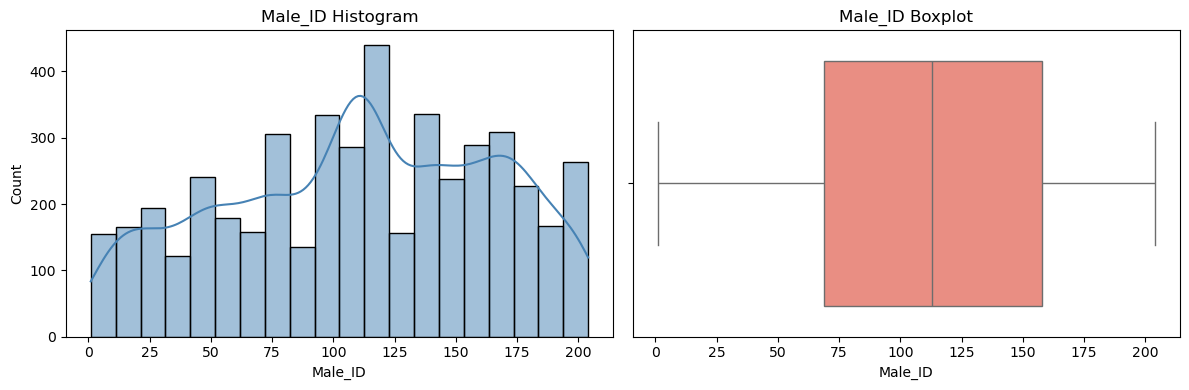

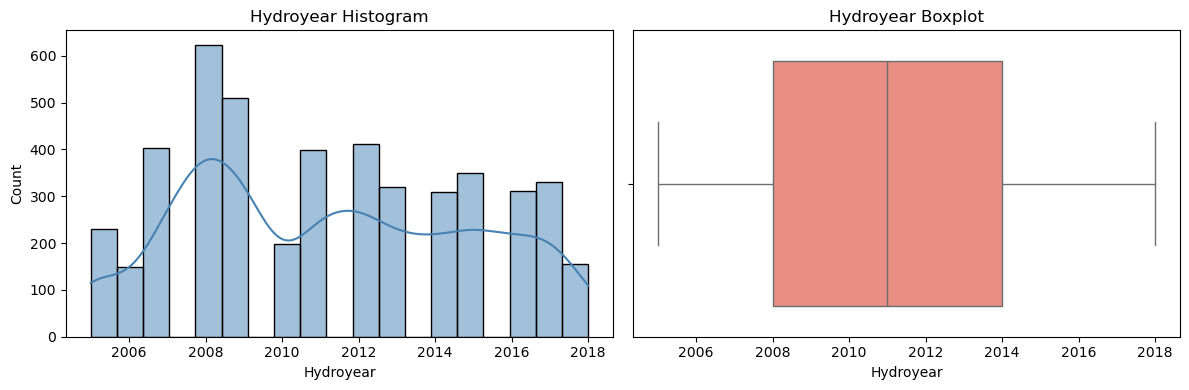

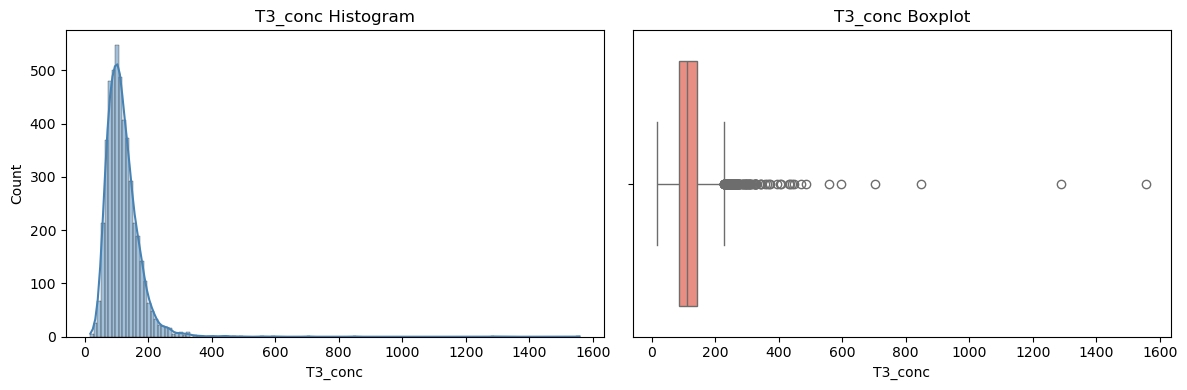

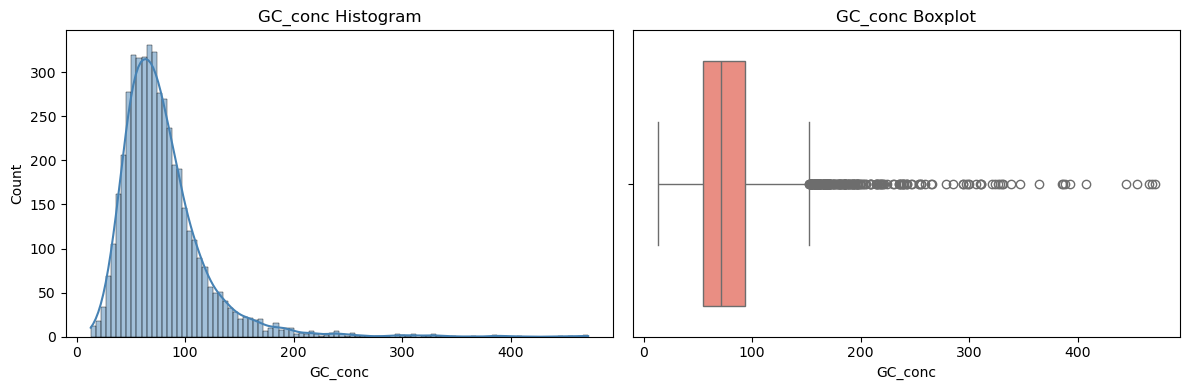

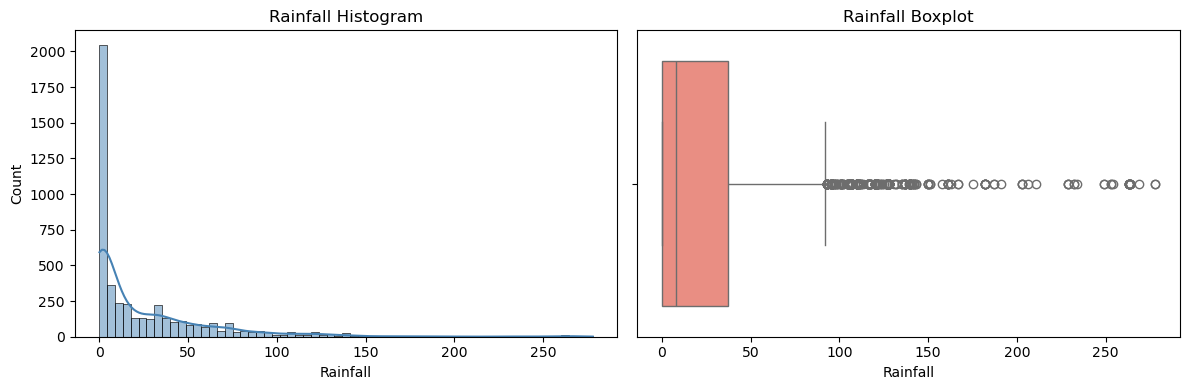

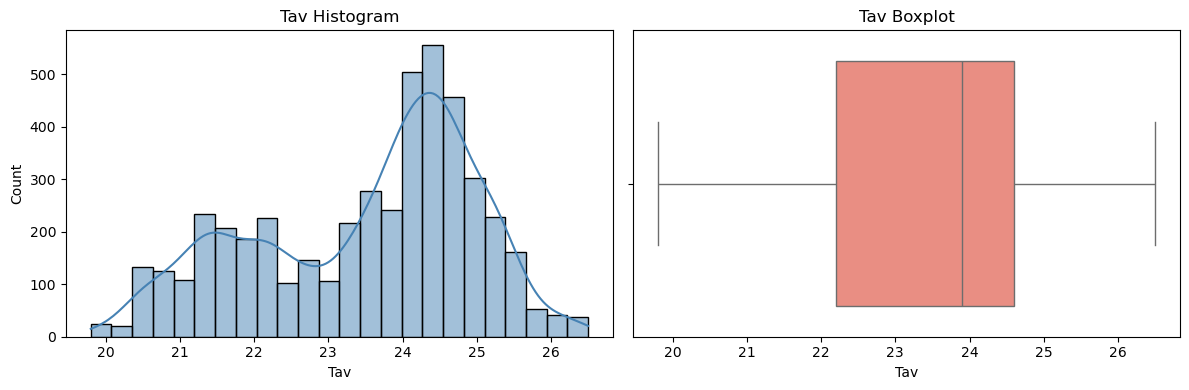

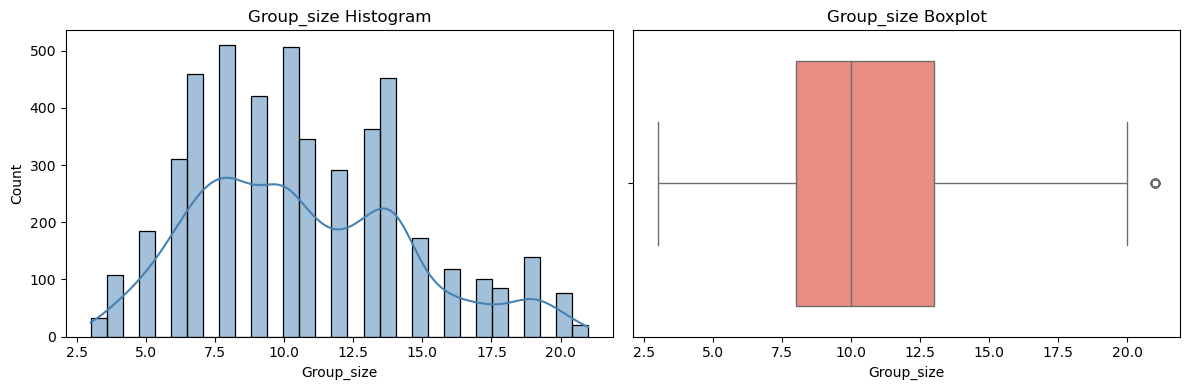

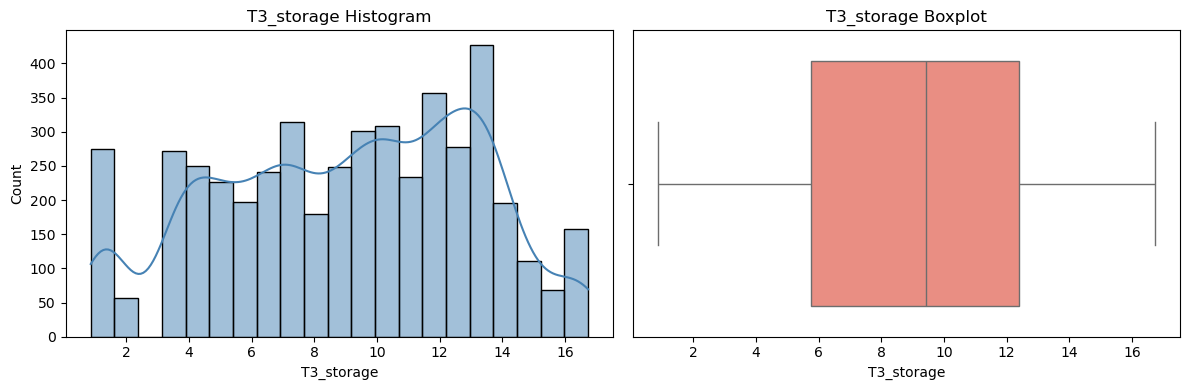

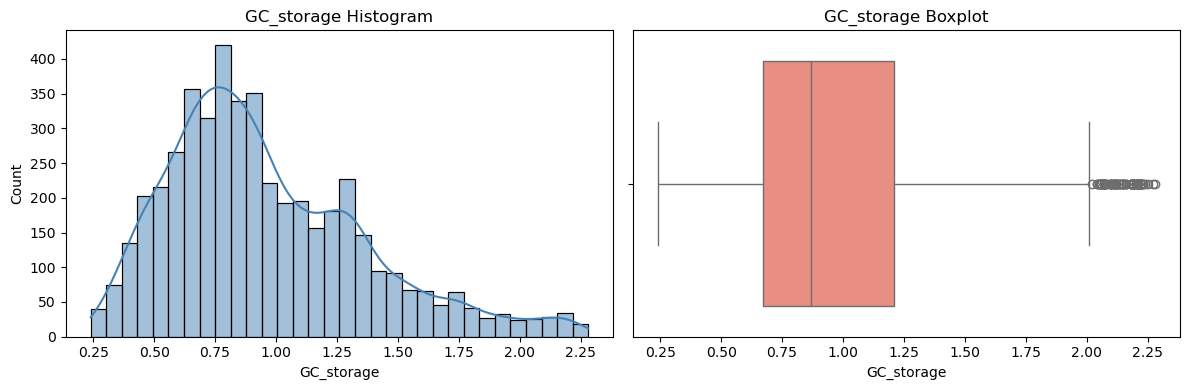

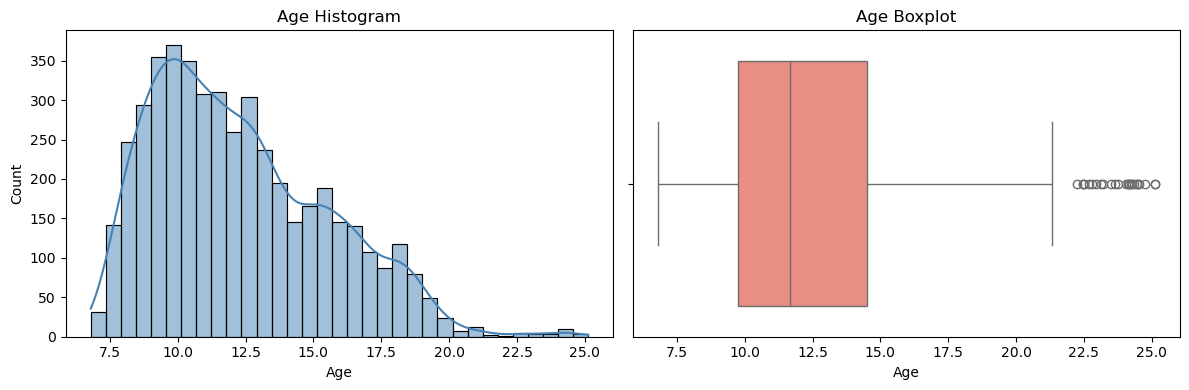

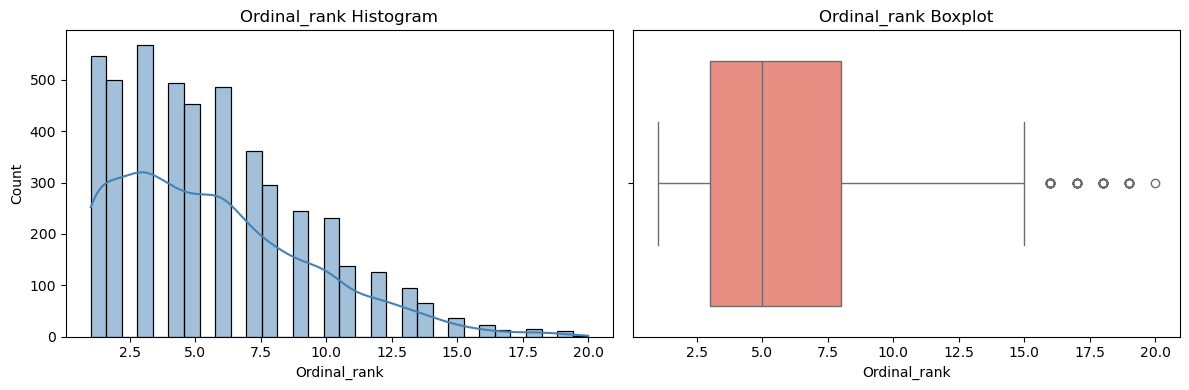

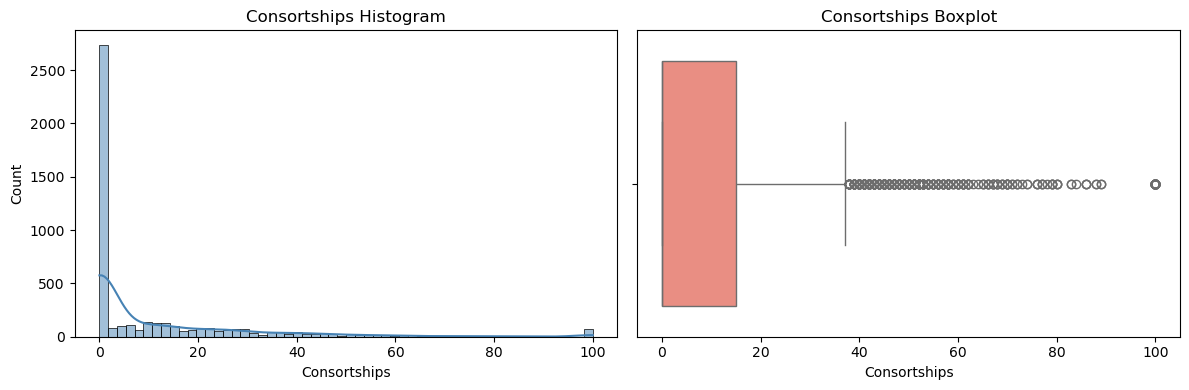

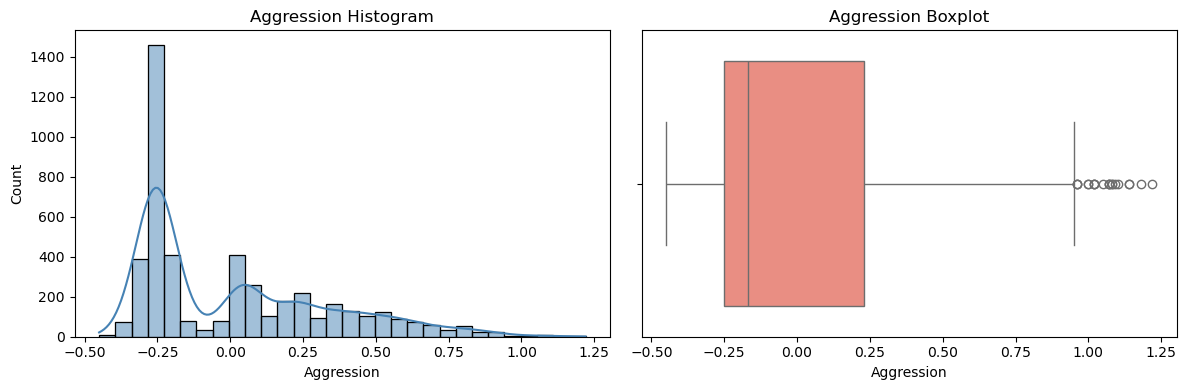

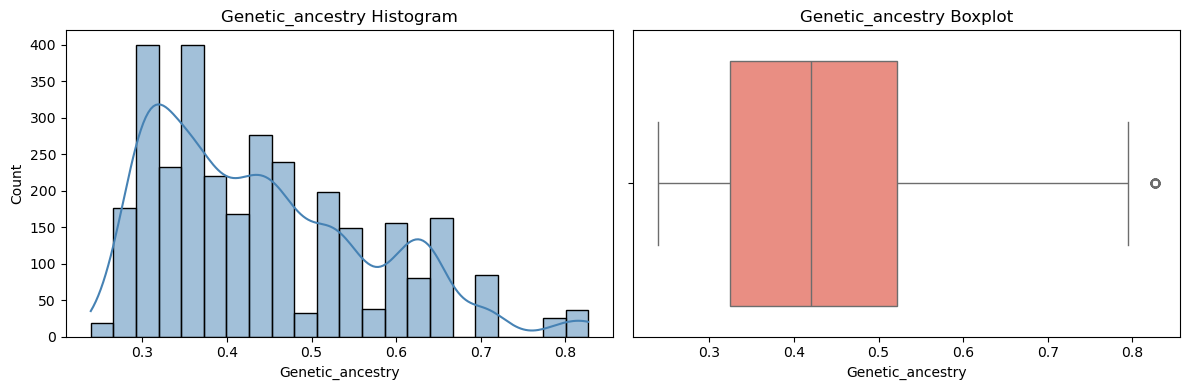

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include="number").columns

for col in numeric_cols:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram
    sns.histplot(df[col], kde=True, ax=ax[0], color="steelblue")
    ax[0].set_title(f"{col} Histogram")

    # Boxplot
    sns.boxplot(x=df[col], ax=ax[1], color="salmon")
    ax[1].set_title(f"{col} Boxplot")

    plt.tight_layout()
    plt.show()

## Boxplots of Hormone Levels by Social Rank

/var/folders/d4/7hnqkf590kq0584z80jkl84w0000gn/T/ipykernel_19584/3531450460.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Ordinal_rank", y=h, data = df, palette="Spectral")


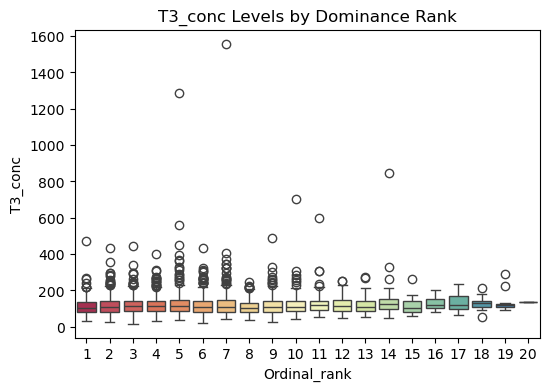

/var/folders/d4/7hnqkf590kq0584z80jkl84w0000gn/T/ipykernel_19584/3531450460.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Ordinal_rank", y=h, data = df, palette="Spectral")


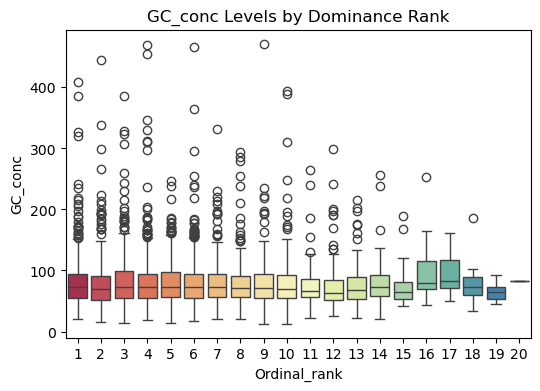

In [18]:
hormones = ["T3_conc", "GC_conc"]  

for h in hormones:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="Ordinal_rank", y=h, data = df, palette="Spectral")
    plt.title(f"{h} Levels by Dominance Rank")
    plt.show()


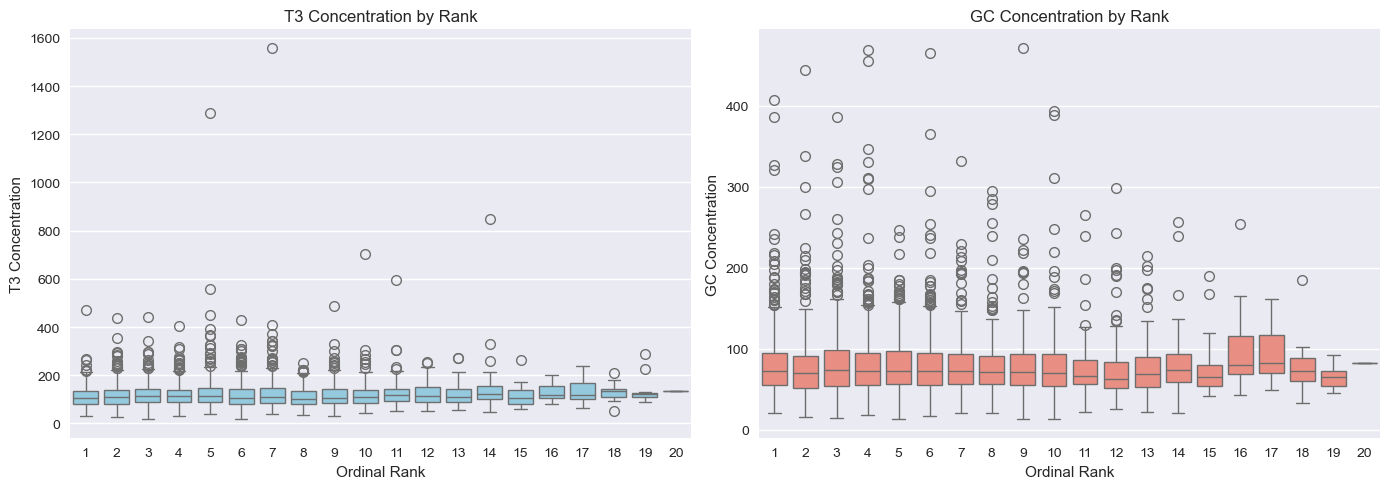

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    x="Ordinal_rank",
    y="T3_conc",
    data=df,
    color="skyblue",
    ax=ax[0]
)
ax[0].set_title("T3 Concentration by Rank")
ax[0].set_xlabel("Ordinal Rank")
ax[0].set_ylabel("T3 Concentration")

sns.boxplot(
    x="Ordinal_rank",
    y="GC_conc",
    data=df,
    color="salmon",
    ax=ax[1]
)
ax[1].set_title("GC Concentration by Rank")
ax[1].set_xlabel("Ordinal Rank")
ax[1].set_ylabel("GC Concentration")

plt.tight_layout()
plt.show()


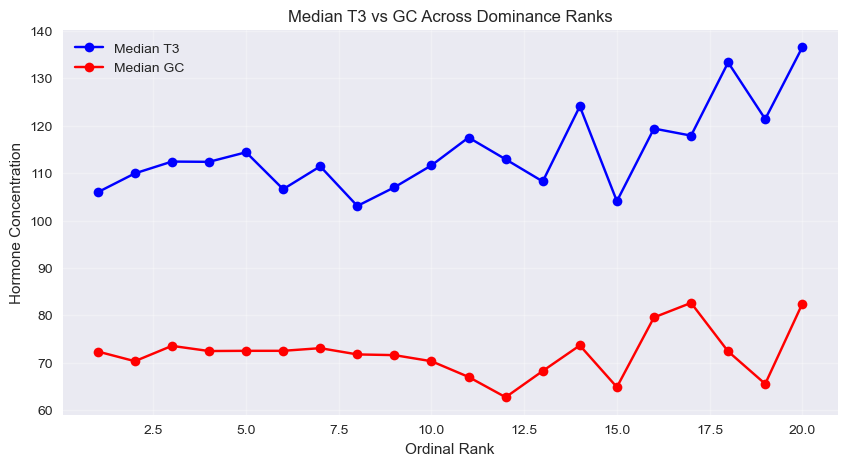

In [25]:
##Direct comparison of Median T3 and Median GC Across Ranks

rank_summary = df.groupby("Ordinal_rank")[["T3_conc", "GC_conc"]].median()

plt.figure(figsize=(10,5))
plt.plot(rank_summary.index, rank_summary["T3_conc"], marker="o", label="Median T3", color="blue")
plt.plot(rank_summary.index, rank_summary["GC_conc"], marker="o", label="Median GC", color="red")

plt.title("Median T3 vs GC Across Dominance Ranks")
plt.xlabel("Ordinal Rank")
plt.ylabel("Hormone Concentration")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


I like this because it shows the different patterns of T3 and GC across ranks. 
- T3 line rises at certainn ranks likely because of more aggression, mate guarding, or competition for resources which increase metabolic rate.
- T3 peaks in the lower ranks
- GC line is mostly flat.
- Stress levels are not as varied across ranks compared to T3.